# Lab 1

In [1]:
from torchvision import datasets, transforms
import torch
from torch.utils.data import DataLoader


data_path_str = "./data"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.backends.cudnn.deterministic=True

transform = transforms.Compose([
    transforms.ToTensor(),
    # normalize by training set mean and standard deviation
    # resulting data has mean=0 and std=1
    transforms.Normalize((0.1307,), (0.3081,))
])

train_dataset = datasets.MNIST(data_path_str, train=True, download=True, transform=transform)
test_loader = DataLoader(
    datasets.MNIST(data_path_str, train=False, download=False, transform=transform),
    # decrease batch size if running into memory issues when testing
    # a bespoke generator is passed to avoid reproducibility issues
    shuffle=False, drop_last=False, batch_size=10000, generator=torch.Generator())

In [2]:
import torch.nn as nn
import torch.nn.functional as F


class MnistCnn(nn.Module):
    def __init__(self):
        super(MnistCnn, self).__init__()

        self.conv1 = nn.Conv2d(1, 32, 3, 1)
        self.conv2 = nn.Conv2d(32, 64, 3, 1)
        self.dropout1 = nn.Dropout(0.25)
        self.dropout2 = nn.Dropout(0.5)
        self.fc1 = nn.Linear(9216, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.conv1(x)
        x = F.relu(x)
        x = self.conv2(x)
        x = F.relu(x)
        x = F.max_pool2d(x, 2)
        x = self.dropout1(x)
        x = torch.flatten(x, 1)
        x = self.fc1(x)
        x = F.relu(x)
        x = self.dropout2(x)
        x = self.fc2(x)
        output = F.log_softmax(x, dim=1)

        return output

In [3]:
from torch.optim import Optimizer


def train_epoch(model: torch.nn.Module, loader: DataLoader, optimizer: Optimizer) -> None:
    model.train()

    for data, target in loader:
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()
        output = model(data)
        loss = F.nll_loss(output, target)
        loss.backward()
        optimizer.step()

In [4]:
import numpy as np
import numpy.random as npr
from torch.utils.data import Subset
from typing import cast


def split(nr_clients: int, iid: bool, seed: int) -> list[Subset]:
    rng = npr.default_rng(seed)

    if iid:
        splits = np.array_split(rng.permutation(len(train_dataset)), nr_clients)
    else:
        sorted_indices = np.argsort(np.array([target for _data, target in train_dataset]))
        shards = np.array_split(sorted_indices, 2 * nr_clients)
        shuffled_shard_indices = rng.permutation(len(shards))
        splits = [
            np.concatenate([shards[i] for i in inds], dtype=np.int64)
            for inds in shuffled_shard_indices.reshape(-1, 2)]

    return [Subset(train_dataset, split) for split in cast(list[list[int]], splits)]

In [5]:
sample_split = split(100, True, 42)

In [6]:
from dataclasses import dataclass, field, asdict
from pandas import DataFrame


@dataclass
class RunResult:
    algorithm: str
    n: int
    c: float
    b: int  # take -1 as inf
    e: int
    lr: float
    seed: int
    wall_time: list[float] = field(default_factory=list)
    message_count: list[int] = field(default_factory=list)
    test_accuracy: list[float] = field(default_factory=list)

    def as_df(self) -> DataFrame:
        self_dict = {
            k.capitalize().replace("_", " "): v
            for k, v in asdict(self).items()}

        if self_dict["B"] == -1:
            self_dict["B"] = "\N{INFINITY}"

        df = DataFrame({"Round": range(1, len(self.wall_time) + 1), **self_dict})
        df = df.rename(columns={"Lr": "\N{GREEK SMALL LETTER ETA}"})
        df = df.drop(columns=["Wall time"])
        return df

In [7]:
from abc import ABC, abstractmethod
from torch.optim import SGD


class Client(ABC):
    def __init__(self, client_data: Subset, batch_size: int) -> None:
        self.model = MnistCnn().to(device)
        self.generator = torch.Generator()
        self.loader_train = DataLoader(
            client_data, batch_size=batch_size, shuffle=True,
            drop_last=False, generator=self.generator)


    @abstractmethod
    def update(self, weights: list[torch.Tensor], seed: int) -> list[torch.Tensor]:
        ...

In [8]:
class Server(ABC):
    def __init__(self, lr: float, batch_size: int, seed: int) -> None:
        self.clients: list[Client]
        self.lr = lr
        self.batch_size = batch_size
        self.seed = seed
        torch.manual_seed(seed)
        self.model = MnistCnn().to(device)


    @abstractmethod
    def run(self, nr_rounds: int, seed: int) -> RunResult:
        ...


    def test(self) -> float:
        correct = 0
        self.model.eval()

        with torch.no_grad():
            for data, target in test_loader:
                data, target = data.to(device), target.to(device)
                output = self.model(data)
                pred = output.argmax(dim=1, keepdim=True)
                correct += pred.eq(target.view_as(pred)).sum().item()

        return 100. * correct / len(cast(datasets.MNIST, test_loader.dataset))

In [9]:
from time import perf_counter
from tqdm import tqdm


class CentralizedServer(Server):
    def __init__(self, lr: float, batch_size: int, seed: int) -> None:
        super().__init__(lr, batch_size, seed)
        self.optimizer = SGD(params=self.model.parameters(), lr=lr)
        self.generator = torch.Generator()
        self.loader_train = DataLoader(
            train_dataset, batch_size=batch_size, shuffle=True,
            drop_last=False, generator=self.generator)
        self.clients = []

    def run(self, nr_rounds: int) -> RunResult:
        elapsed_time = 0.
        run_result = RunResult("Centralized", 1, 1, self.batch_size, 1, self.lr, self.seed)

        for epoch in tqdm(range(nr_rounds), desc="Epochs", leave=False):
            start_time = perf_counter()
            self.generator.manual_seed(self.seed + epoch + 1)
            train_epoch(self.model, self.loader_train, self.optimizer)
            elapsed_time += perf_counter() - start_time
            run_result.wall_time.append(round(elapsed_time, 1))
            run_result.message_count.append(0)
            run_result.test_accuracy.append(self.test())

        return run_result

In [10]:
centralized_server = CentralizedServer(0.5, 1024, 42)
result_centralized = centralized_server.run(5)
centralized_df = result_centralized.as_df()
centralized_df

,Round,Algorithm,N,C,B,E,η,Seed,Message count,Test accuracy
0,1,Centralized,1,1,1024,1,0.5,42,0,89.89
1,2,Centralized,1,1,1024,1,0.5,42,0,96.70
2,3,Centralized,1,1,1024,1,0.5,42,0,97.71
3,4,Centralized,1,1,1024,1,0.5,42,0,98.12
4,5,Centralized,1,1,1024,1,0.5,42,0,98.40


In [11]:
class DecentralizedServer(Server):
    def __init__(self, lr: float, batch_size: int, client_subsets: list[Subset], client_fraction: float, seed: int) -> None:
        super().__init__(lr, batch_size, seed)
        self.nr_clients = len(client_subsets)
        self.client_fraction = client_fraction
        self.client_sample_counts = [len(subset) for subset in client_subsets]
        self.nr_clients_per_round = max(1, round(client_fraction * self.nr_clients))
        self.rng = npr.default_rng(seed)

# Lab 2

In [12]:
class GradientClient(Client):
    def __init__(self, client_data: Subset) -> None:
        super().__init__(client_data, len(client_data))

    def update(self, weights: list[torch.Tensor], seed: int) -> list[torch.Tensor]:
        with torch.no_grad():
            for client_values, server_values in zip(self.model.parameters(), weights):
                client_values[:] = server_values
                client_values.grad = None

        # seeding is not strictly necessary here
        self.generator.manual_seed(seed)
        self.model.train()

        # this will always have one iteratioon
        for data, target in self.loader_train:
            data, target = data.to(device), target.to(device)
            output = self.model(data)
            loss = F.nll_loss(output, target)
            loss.backward()

        return [
            cast(torch.Tensor, x.grad).detach().cpu().clone()
            for x in self.model.parameters()]

In [13]:
class FedSgdGradientServer(DecentralizedServer):
    def __init__(
            self, lr: float,
            client_subsets: list[Subset], client_fraction: float, seed: int) -> None:
        super().__init__(lr, -1, client_subsets, client_fraction, seed)
        self.optimizer = SGD(params=self.model.parameters(), lr=lr)
        self.clients = [GradientClient(subset) for subset in client_subsets]

    def run(self, nr_rounds: int) -> RunResult:
        elapsed_time = 0.
        run_result = RunResult("FedSGDGradient", self.nr_clients, self.client_fraction, -1, 1, self.lr, self.seed)

        for nr_round in tqdm(range(nr_rounds), desc="Rounds", leave=False):
            setup_start_time = perf_counter()
            self.model.train()
            self.optimizer.zero_grad()
            weights = [x.detach().cpu().clone() for x in self.model.parameters()]
            indices_chosen_clients = self.rng.choice(self.nr_clients, self.nr_clients_per_round, replace=False)
            chosen_sum_nr_samples = sum(self.client_sample_counts[i] for i in indices_chosen_clients)
            chosen_adjusted_gradients: list[list[torch.Tensor]] = []
            elapsed_time += perf_counter() - setup_start_time
            update_time = 0.

            for c_i in indices_chosen_clients:
                update_start_time = perf_counter()
                ind = int(c_i)
                client_round_seed = self.seed + ind + 1 + nr_round * self.nr_clients_per_round
                client_gradients = self.clients[ind].update(weights, client_round_seed)
                chosen_adjusted_gradients.append([
                    self.client_sample_counts[ind] / chosen_sum_nr_samples * tens
                     for tens in client_gradients])
                update_time = max(update_time, perf_counter() - update_start_time)

            elapsed_time += update_time
            aggregate_start_time = perf_counter()
            averaged_chosen_gradients: list[torch.Tensor] = [sum(x) for x in zip(*chosen_adjusted_gradients)]

            with torch.no_grad():
                for client_gradient, server_parameter in zip(averaged_chosen_gradients, self.model.parameters()):
                    server_parameter.grad = client_gradient.to(device=device)

            self.optimizer.step()
            elapsed_time += perf_counter() - aggregate_start_time
            run_result.wall_time.append(round(elapsed_time, 1))
            run_result.message_count.append(2 * (nr_round + 1) * self.nr_clients_per_round)
            run_result.test_accuracy.append(self.test())

        return run_result

In [14]:
fedsgd_gradient_server = FedSgdGradientServer(0.01, sample_split, 0.2, 42)
result_fedsgd_gradient = fedsgd_gradient_server.run(5)
fedsgd_gradient_df = result_fedsgd_gradient.as_df()
fedsgd_gradient_df

,Round,Algorithm,N,C,B,E,η,Seed,Message count,Test accuracy
0,1,FedSGDGradient,100,0.2,∞,1,0.01,42,40,8.80
1,2,FedSGDGradient,100,0.2,∞,1,0.01,42,80,9.04
2,3,FedSGDGradient,100,0.2,∞,1,0.01,42,120,9.34
3,4,FedSGDGradient,100,0.2,∞,1,0.01,42,160,9.57
4,5,FedSGDGradient,100,0.2,∞,1,0.01,42,200,9.83


In [15]:
class WeightClient(Client):
    def __init__(self, client_data: Subset, lr: float, batch_size: int, nr_epochs: int) -> None:
        super().__init__(client_data, batch_size)
        self.optimizer = SGD(params=self.model.parameters(), lr=lr)
        self.nr_epochs = nr_epochs


    def update(self, weights: list[torch.Tensor], seed: int) -> list[torch.Tensor]:
        with torch.no_grad():
            for client_values, server_values in zip(self.model.parameters(), weights):
                client_values[:] = server_values

        self.generator.manual_seed(seed)

        for _epoch in range(self.nr_epochs):
            train_epoch(self.model, self.loader_train, self.optimizer)

        return [x.detach().cpu().clone() for x in self.model.parameters()]

In [16]:
class FedAvgServer(DecentralizedServer):
    def __init__(
            self, lr: float, batch_size: int, client_subsets: list[Subset],
            client_fraction: float, nr_local_epochs: int, seed: int) -> None:
        super().__init__(lr, batch_size, client_subsets, client_fraction, seed)
        self.name = "FedAvg"
        self.nr_local_epochs = nr_local_epochs
        self.clients = [
            WeightClient(subset, lr, batch_size, nr_local_epochs)
            for subset in client_subsets]

    def run(self, nr_rounds: int) -> RunResult:
        elapsed_time = 0.
        run_result = RunResult(self.name, self.nr_clients, self.client_fraction, self.batch_size, self.nr_local_epochs, self.lr, self.seed)

        for nr_round in tqdm(range(nr_rounds), desc="Rounds", leave=False):
            setup_start_time = perf_counter()
            self.model.train()
            weights = [x.detach().cpu().clone() for x in self.model.parameters()]
            indices_chosen_clients = self.rng.choice(self.nr_clients, self.nr_clients_per_round, replace=False)
            chosen_sum_nr_samples = sum(self.client_sample_counts[i] for i in indices_chosen_clients)
            chosen_adjusted_weights: list[list[torch.Tensor]] = []
            elapsed_time += perf_counter() - setup_start_time
            update_time = 0.

            for c_i in indices_chosen_clients:
                update_start_time = perf_counter()
                ind = int(c_i)
                client_round_seed = self.seed + ind + 1 + nr_round * self.nr_clients_per_round
                client_weights = self.clients[ind].update(weights, client_round_seed)
                chosen_adjusted_weights.append([
                    self.client_sample_counts[ind] / chosen_sum_nr_samples * tens
                     for tens in client_weights])
                update_time = max(update_time, perf_counter() - update_start_time)

            elapsed_time += update_time
            aggregate_start_time = perf_counter()
            averaged_chosen_weights: list[torch.Tensor] = [sum(x) for x in zip(*chosen_adjusted_weights)]

            with torch.no_grad():
                for client_weight, server_parameter in zip(averaged_chosen_weights, self.model.parameters()):
                    server_parameter[:] = client_weight.to(device=device)

            elapsed_time += perf_counter() - aggregate_start_time
            run_result.wall_time.append(round(elapsed_time, 1))
            run_result.message_count.append(2 * (nr_round + 1) * self.nr_clients_per_round)
            run_result.test_accuracy.append(self.test())

        return run_result

In [17]:
fedavg_server = FedAvgServer(0.01, 100, sample_split, 0.2, 2, 42)
result_fedavg = fedavg_server.run(5)
fedavg_df = result_fedavg.as_df()
fedavg_df

,Round,Algorithm,N,C,B,E,η,Seed,Message count,Test accuracy
0,1,FedAvg,100,0.2,100,2,0.01,42,40,23.77
1,2,FedAvg,100,0.2,100,2,0.01,42,80,54.73
2,3,FedAvg,100,0.2,100,2,0.01,42,120,68.16
3,4,FedAvg,100,0.2,100,2,0.01,42,160,74.84
4,5,FedAvg,100,0.2,100,2,0.01,42,200,77.48


In [18]:
class FedSgdWeightServer(FedAvgServer):
    def __init__(
            self, lr: float, client_subsets: list[Subset],
            client_fraction: float, seed: int) -> None:
        # any batch size larger than each client's dataset is effectively infinite
        super().__init__(lr, len(train_dataset), client_subsets, client_fraction, 1, seed)
        self.batch_size = -1
        self.name = "FedSGDWeight"

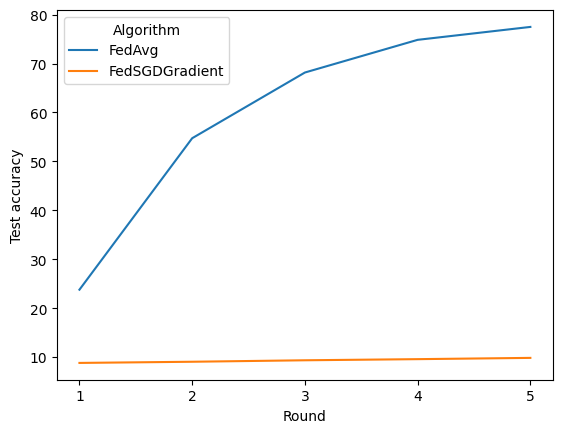

In [19]:
import pandas as pd
import seaborn as sns


df = pd.concat([fedavg_df, fedsgd_gradient_df], ignore_index=True)
ax = sns.lineplot(df, x="Round", y="Test accuracy", hue="Algorithm", seed=0)
_ = ax.set_xticks(df["Round"].unique())

# Homework 1

In [20]:
fedsgd_weight_server = FedSgdWeightServer(0.01, sample_split, 0.5, 42)
result_fedsgd_weight = fedsgd_weight_server.run(5)
fedsgd_weight_df = result_fedsgd_weight.as_df()
fedsgd_weight_df

,Round,Algorithm,N,C,B,E,η,Seed,Message count,Test accuracy
0,1,FedSGDWeight,100,0.5,∞,1,0.01,42,100,8.91
1,2,FedSGDWeight,100,0.5,∞,1,0.01,42,200,9.15
2,3,FedSGDWeight,100,0.5,∞,1,0.01,42,300,9.43
3,4,FedSGDWeight,100,0.5,∞,1,0.01,42,400,9.62
4,5,FedSGDWeight,100,0.5,∞,1,0.01,42,500,9.80
